# Projet 6 - Initiez-vous au MLOps (partie 1/2)


**Objectif du projet**  
Prédire la probabilité de défaut de paiement d'un client (TARGET = 1)  
→ Problème de **classification binaire déséquilibrée**

**Approche MLOps visée dans cette première partie**  
- Suivi systématique des expériences avec **MLflow**  
- Comparaison de plusieurs modèles / jeux de features  
- Versionning des modèles  



Date : Janvier 2026  
Auteur : Joannes Landy

## Étape 2 - Traquez les expérimentations avec MLFlow

Objectifs:

Des runs visibles dans l’UI MLflow avec les paramètres testés et les scores obtenus.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mlflow
import os


# configuration des paramètres de connexion et des répertoires de travail
MLFLOW_URL = "http://localhost:5000"
DATA_DIR = str(Path.home() / "data")
EXPERIMENT_NAME = "Projet 06 - OpenClassrooms v4"


In [2]:
from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier


from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import confusion_matrix, classification_report


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline


import time


output_file = DATA_DIR + "/processed/application_train_processed.parquet"
df_prepossessed = pd.read_parquet(output_file)
    
# Création du jeu de test/train
random_state = 42
test_size = 0.2
target = 'TARGET'

# Split X and y
X = df_prepossessed.drop(columns=[target])
y = df_prepossessed[target]


display("X shape;", X.shape)


'X shape;'

(307511, 21)

In [5]:
from mlflow import MlflowClient
from sklearn.metrics import precision_score, recall_score, make_scorer
from sklearn.impute import SimpleImputer


client = MlflowClient(tracking_uri=MLFLOW_URL)
exp = client.get_experiment_by_name(EXPERIMENT_NAME)


# Liste des modèles pour itération
models = {
    'linear_model': LogisticRegression(),
    'rf_model': RandomForestClassifier(),

}

# Liste des parametres à tester
param_grids = {
    'linear_model': {
        'classifier__random_state': [random_state],
        #'classifier__solver': ['lbfgs'],
        'classifier__C': [0.01, 0.1],
        #'classifier__max_iter': [10, 100, 100],
        'classifier__class_weight': ['balanced'],
    },

    'rf_model': {
        'classifier__random_state': [random_state],
        'classifier__class_weight': ['balanced', 'balanced_subsample'], # autre strategie
        'classifier__n_estimators': [100, 250, 500],
        'classifier__max_depth': [3, 5, 7],
        #'min_samples_split': [2, 5, 10],
        #'min_samples_leaf': [1, 2, 4]
    },

}

# reseau de neurone : MLP, plsuieur package a explorer, pytorch,

# chercher et Stocker les meilleurs modèles

def search_bestmodel(models, param_grids, X, y):
    """ Use GridSearchCV to find best parameter, return the best model"""
    best_models = {}
    for name, model in models.items():
        print(f"\nEntraînement de {name}...")
        
        numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
        categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()



        # Pipeline numérique
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),  # robuste aux outliers
            ("scaler", StandardScaler())
        ])
        
        # Pipeline catégoriel
        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),  
            ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ])
        
        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, numeric_features),
                ("cat", categorical_transformer, categorical_features),
            ]
        )
        
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])



        def custom_score(y_true, y_pred):
            precision = precision_score(y_true, y_pred)
            recall = recall_score(y_true, y_pred)
            return (precision + 10 * recall) / 11.0
        
        custom_scorer = make_scorer(custom_score)
        
        # GridSearchCV
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            scoring=custom_scorer,
            cv=5,                  # validation croisée à 5 folds
            n_jobs=-1,             # utiliser tous les cœurs
            verbose=1              # afficher la progression
        )
        
        # Ajuster sur les données d'entraînement
        grid.fit(X, y)
        
        # Sauvegarder le meilleur modèle
        best_models[name] = grid.best_estimator_

        results_df = pd.DataFrame(grid.cv_results_)
        for index, row in results_df.iterrows():
            run = client.create_run(experiment_id=exp.experiment_id)
            run_id = run.info.run_id
            client.set_tag(run_id, "model_type", name)

            client.log_metric(run_id, "custom_metric", row['mean_test_score'])
            
            for key, value in row['params'].items():
                client.log_param(run_id, key.replace('classifier__', ''), value)
            client.set_terminated(run_id, status="FINISHED")
            
        
        print(f"Meilleurs paramètres : {grid.best_params_}")
        print(f"Meilleur score custom : {grid.best_score_:.4f}")
    
    return best_models


best_models = search_bestmodel(models, param_grids, X, y)
print('-------end--------')


Entraînement de linear_model...
Fitting 5 folds for each of 2 candidates, totalling 10 fits


/home/joannes/Documents/openclassroom/06_Initiez_vous_au_MLOps_1-2/openclassrooms_projet06/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/joannes/Documents/openclassroom/06_Initiez_vous_au_MLOps_1-2/openclassrooms_projet06/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to im

🏃 View run crawling-sheep-968 at: http://localhost:5000/#/experiments/4/runs/ac5898d6f7904eea9b97c41499937337
🧪 View experiment at: http://localhost:5000/#/experiments/4
🏃 View run bouncy-moth-540 at: http://localhost:5000/#/experiments/4/runs/aadcd4ec007c4a0e8137b6579306cd04
🧪 View experiment at: http://localhost:5000/#/experiments/4
Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__random_state': 42}
Meilleur score custom : 0.6205

Entraînement de rf_model...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
🏃 View run unique-wasp-263 at: http://localhost:5000/#/experiments/4/runs/995e8d3a04544b9992cf735d3271cb02
🧪 View experiment at: http://localhost:5000/#/experiments/4
🏃 View run smiling-bear-66 at: http://localhost:5000/#/experiments/4/runs/e0b290c49f1046438fc75c77706f73f7
🧪 View experiment at: http://localhost:5000/#/experiments/4
🏃 View run youthful-gnat-319 at: http://localhost:5000/#/experiments/4/runs/1e087e1c26b041

### Meilleur modèle et sauvegarde

Meilleurs paramètres : {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__random_state': 42}
Meilleur score custom : 0.6275

Le critere d'optimisation est une metrique metier qui est :
(precision + 10 * recall) / 11.0

L'objectif est de maximiser le nombre de défauts de paiement trouvé.

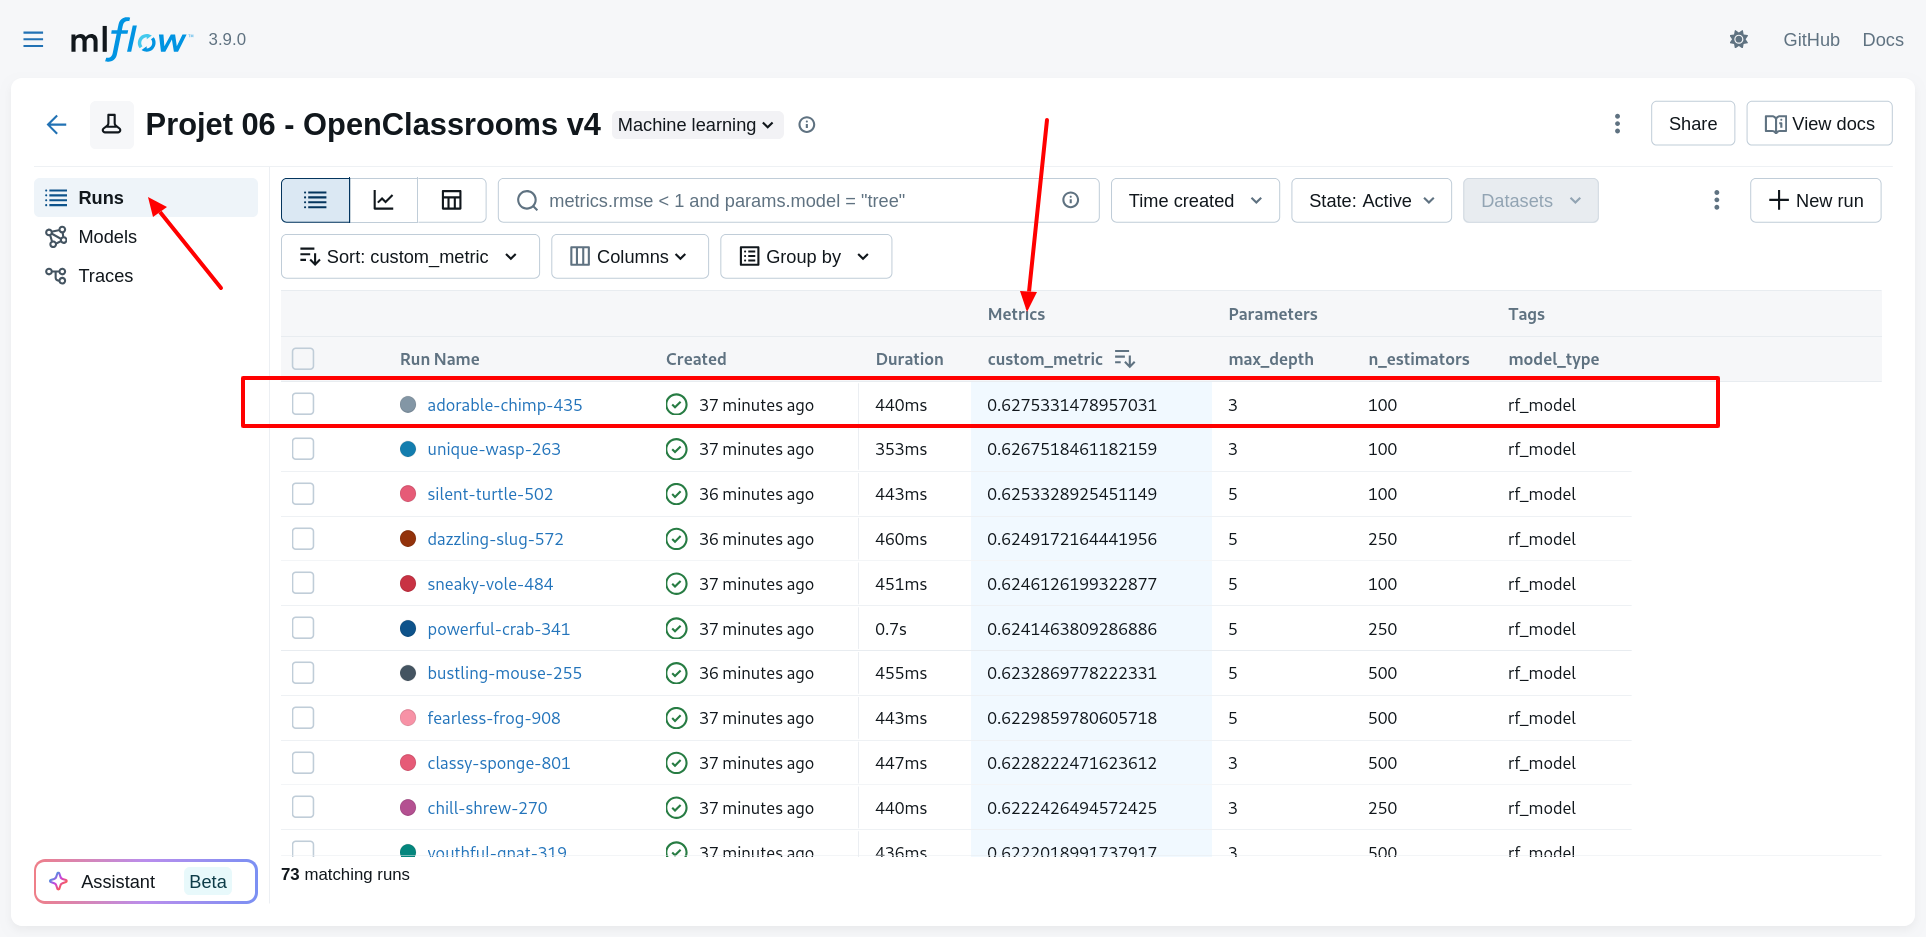

In [7]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri(MLFLOW_URL)
mlflow.set_experiment(EXPERIMENT_NAME)

for name, model in best_models.items():

    with mlflow.start_run(run_name=f"{name}_model"):

        # Log type du modèle
        classifier_type = type(model.named_steps["classifier"]).__name__
        mlflow.set_tag("model_type", classifier_type)

        # Log paramètres du classifier uniquement
        classifier_params = model.named_steps["classifier"].get_params()
        mlflow.log_params(classifier_params)

        # Sauvegarde du pipeline complet
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model"
        )

2026/03/03 16:43:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/joannes/Documents/openclassroom/06_Initiez_vous_au_MLOps_1-2/openclassrooms_projet06/.venv/lib/python3.13/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)
2026/03/03 16:43:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run linear_model_model at: http://localhost:5000/#/experiments/4/runs/5bae16d79db3428f882ba65682a0626d
🧪 View experiment at: http://localhost:5000/#/experiments/4


2026/03/03 16:43:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 16:43:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run rf_model_model at: http://localhost:5000/#/experiments/4/runs/a3417deb66c443108bc6c97ab3edea5d
🧪 View experiment at: http://localhost:5000/#/experiments/4



Voici l'enregistrement du model dans MLflow:

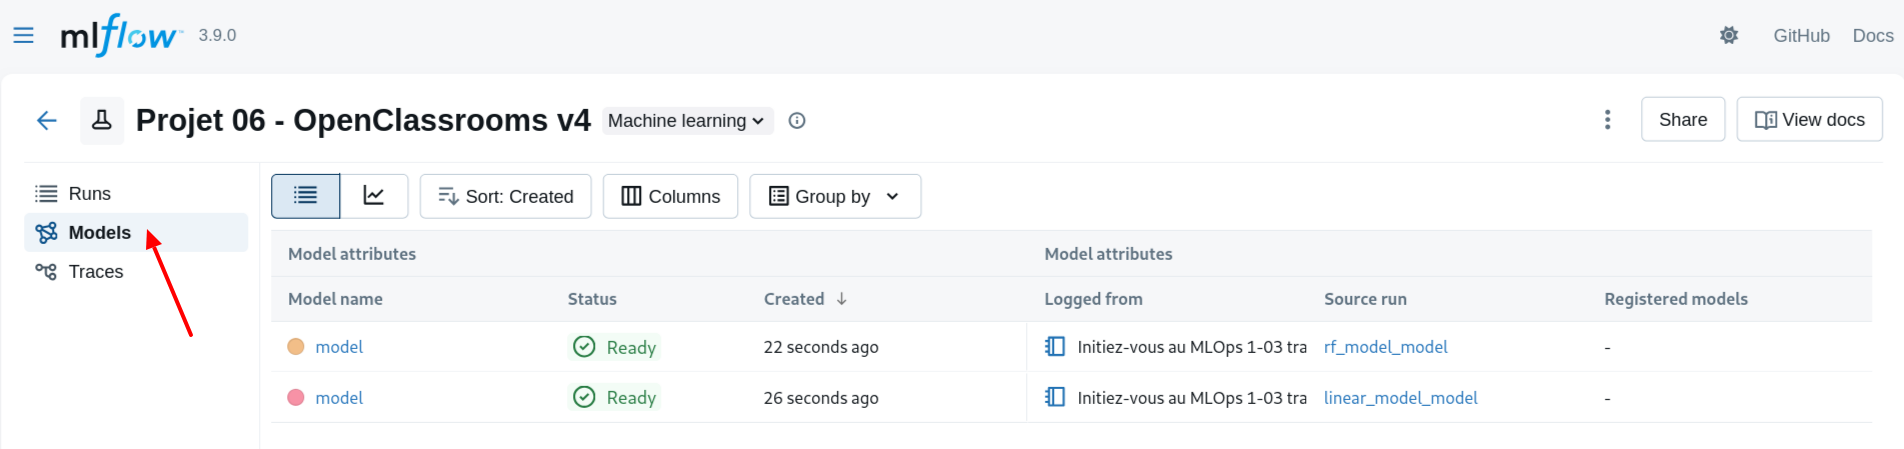
